# Apple Quality on Machine and Deep Learning Models

In [1]:
# Uncomment following lines in case packages are not installed.

# !pip install tensorflow
# !pip install tensorflow_hub

In [2]:
%%capture

# Imports common libraries.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random, itertools, os, datetime
import kagglehub, shutil

from pathlib import Path
from importlib import reload

In [3]:
# Imports helper_functions module.
import extras.helper_functions as hf;
from importlib import reload;
reload(hf);

In [4]:
print(tf.__version__)

2.19.0


* The following lines download and move at separate directory dataset. In case dataset missing or never downloaded, uncommet the lines to proceed the execution.
* For speeding up the simulations, the following cell is commented out.

In [5]:
# # Downloads dataset file.
# import kagglehub, shutil
# from pathlib import Path

# current_path = str(Path.cwd())
# if not os.path.isdir('dataset'):
#     temp_path = kagglehub.dataset_download("nelgiriyewithana/apple-quality") # latest version
#     if os.name == "nt": # checks operating system ("nt" => windows)
#         shutil.copytree(temp_path, current_path + "\\dataset") # copies files into current directory
#         shutil.rmtree(temp_path.split("kagglehub")[0] + "kagglehub") # removes download files into "kagglehub": directory
#     else:
#         shutil.copytree(temp_path, current_path + "/dataset")

## 1. Loading and Visualizing of data

### 1.1 Loading Data

In [6]:
df = pd.read_csv("dataset/apple_quality.csv", delimiter = ',', skipfooter = 1)

In [7]:
df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good


In [8]:
df.tail()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
3995,3995,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784,bad
3996,3996,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235,good
3997,3997,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611,bad
3998,3998,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229720,good
3999,3999,0.278540,-1.715505,0.121217,-1.154075,1.266677,-0.776571,1.599796,good


### 1.2 Sub-dataFrame of min and max values from original dataframe.

In [9]:
# Creates a DataFrame containing min/max values of independent variables and possible values of dependent variable.
column_headers = list(df.columns.values)
df_values_stats = pd.DataFrame({v: [df[v].min(), df[v].max()] for k, v in enumerate(column_headers[:-1])}, index = ["min", "max"])
df_values_stats[column_headers[-1]] = sorted(df["Quality"].unique())
df_values_stats

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
min,0,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538,bad
max,3999,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736,good


### 1.3 Visualizing data in graphs

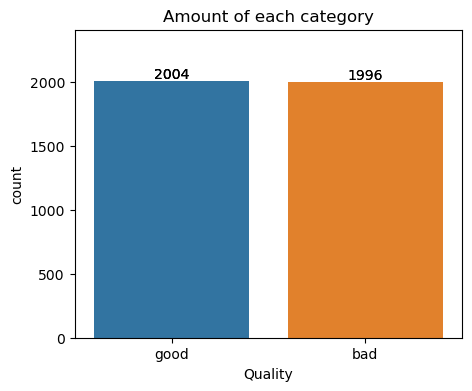

In [21]:
# Visualizing the amount of "Quality", which is separated in two categories.
plt.figure(figsize = (5, 4), dpi = 100)
ax = sns.countplot(data = df,
                   x = "Quality",
                   hue = "Quality")
y_max = 0
for container in ax.containers:
    ax.bar_label(container)
    if y_max < int(((ax.bar_label(container)[0]).get_text())):
        y_max = int(((ax.bar_label(container)[0]).get_text()))
plt.title("Amount of each category")
plt.ylim(0, round(y_max + (y_max * 0.2)));